# ⭐ Yelp Review Dataset — Complete EDA
**File:** `yelp_academic_dataset_review.json`

**Schema:**
- `review_id` — Unique 22-char review ID
- `user_id` — Author's user ID
- `business_id` — Target business ID
- `stars` — Star rating (1–5)
- `date` — Review date (YYYY-MM-DD)
- `text` — Review text
- `useful`, `funny`, `cool` — Votes received

## 0 · Configuration — UPDATE FILE PATH BEFORE RUNNING

In [0]:
FILE_PATH = "/Volumes/exam_catalog/default/smvitaproject/part-00000-tid-7593837501419686833-faed17af-7d5a-49a1-ba1c-75585b2cc9ef-168-1.c000.snappy.parquet"   # <-- change if needed
SAMPLE_FOR_TEXT = 200_000   # Use a sample for heavy text analysis (set None to use all)

## 1 · Imports & Setup

In [0]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})

## 2 · Load Data 

In [0]:
df = pd.read_parquet(FILE_PATH)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["stars"] = pd.to_numeric(df["stars"], errors="coerce")
for col in ["useful","funny","cool"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

print(f"Shape: {df.shape}")
df.dtypes

Shape: (6990280, 9)


business_id            object
cool                    int64
date           datetime64[ns]
funny                   int64
review_id              object
stars                 float64
text                   object
useful                  int64
user_id                object
dtype: object

In [0]:
df["text"]

0          If you decide to eat here, just be aware it is...
1          I've taken a lot of spin classes over the year...
2          Family diner. Had the buffet. Eclectic assortm...
3          Wow!  Yummy, different,  delicious.   Our favo...
4          Cute interior and owner (?) gave us tour of up...
                                 ...                        
6990275    Latest addition to services from ICCU is Apple...
6990276    This spot offers a great, affordable east week...
6990277    This Home Depot won me over when I needed to g...
6990278    For when I'm feeling like ignoring my calorie-...
6990279    Located in the 'Walking District' in Nashville...
Name: text, Length: 6990280, dtype: object

## 3 · Basic Info & Nulls

In [0]:
print("=== Null counts ===")
print(df.isnull().sum())
print("\n=== describe ===")
df[["stars","useful","funny","cool"]].describe()

=== Null counts ===
business_id    0
cool           0
date           0
funny          0
review_id      0
stars          0
text           0
useful         0
user_id        0
dtype: int64

=== describe ===


,stars,useful,funny,cool
count,6.990280e+06,6.990280e+06,6.990280e+06,6.990280e+06
mean,3.748584e+00,1.184609e+00,3.265596e-01,4.986175e-01
std,1.478705e+00,3.253767e+00,1.688729e+00,2.172460e+00
min,1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00
25%,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,5.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
max,5.000000e+00,1.182000e+03,7.920000e+02,4.040000e+02


## 4 · Star Rating Distribution

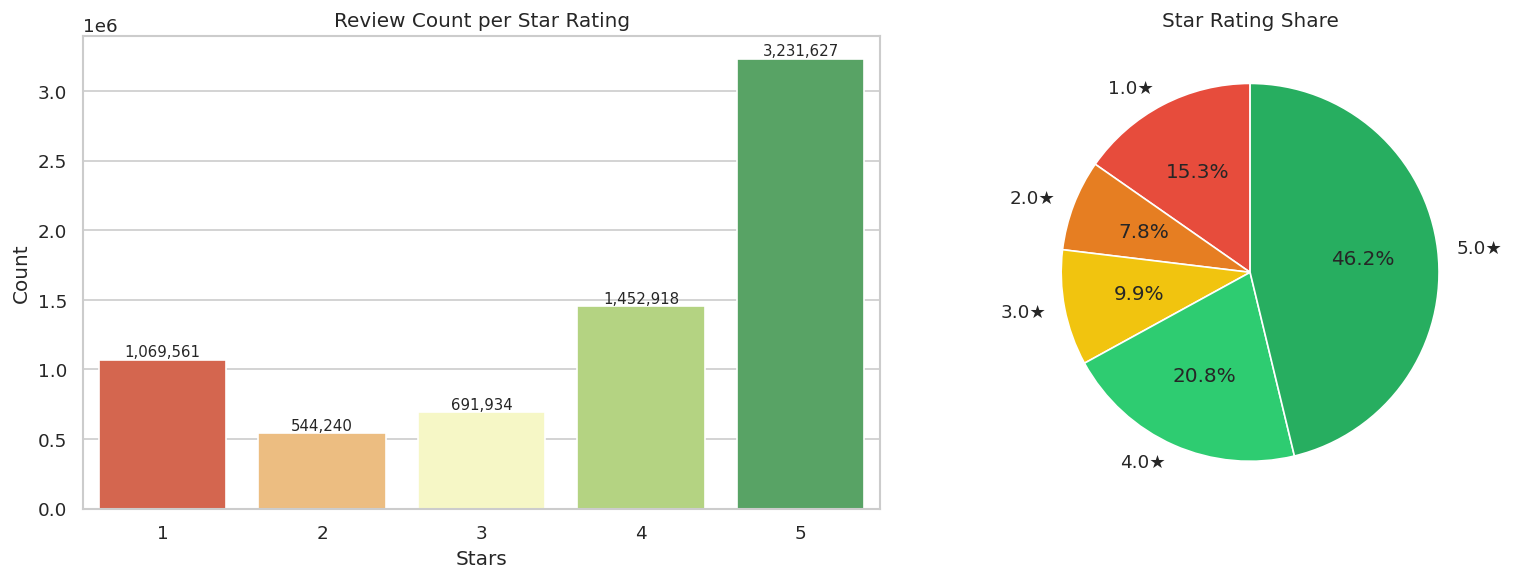

Mean stars: 3.75  |  Median: 4.0


In [0]:
star_counts = df["stars"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=star_counts.index.astype(int), y=star_counts.values, ax=axes[0], palette="RdYlGn")
axes[0].set_title("Review Count per Star Rating")
axes[0].set_xlabel("Stars")
axes[0].set_ylabel("Count")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}", (p.get_x()+p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=9)

pct = star_counts / star_counts.sum() * 100
colors = ["#e74c3c","#e67e22","#f1c40f","#2ecc71","#27ae60"]
axes[1].pie(pct.values, labels=[f"{i}★" for i in star_counts.index],
            autopct="%1.1f%%", colors=colors, startangle=90)
axes[1].set_title("Star Rating Share")

plt.tight_layout()
plt.show()

print(f"Mean stars: {df['stars'].mean():.2f}  |  Median: {df['stars'].median()}")

## 5 · Reviews Over Time

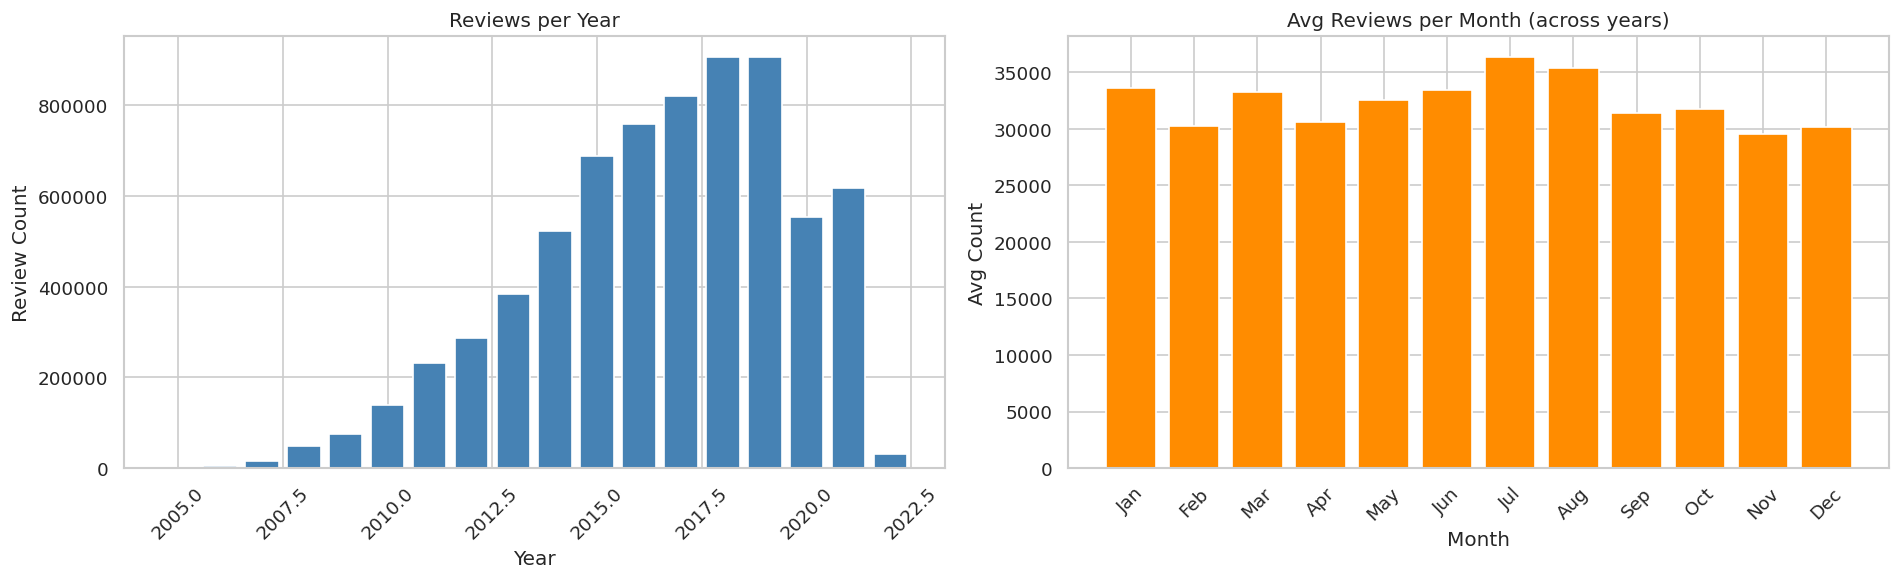

In [0]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["year_month"] = df["date"].dt.to_period("M")

yearly = df.groupby("year").size().reset_index(name="count")
yearly = yearly[yearly["year"].between(2005, 2024)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(yearly["year"], yearly["count"], color="steelblue", edgecolor="white")
axes[0].set_title("Reviews per Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Review Count")
axes[0].tick_params(axis="x", rotation=45)

monthly_avg = df.groupby("month").size() / df["year"].nunique()
axes[1].bar(monthly_avg.index, monthly_avg.values, color="darkorange", edgecolor="white")
axes[1].set_title("Avg Reviews per Month (across years)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Avg Count")
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"], rotation=45)

plt.tight_layout()
plt.show()

## 6 · Average Stars Over Time

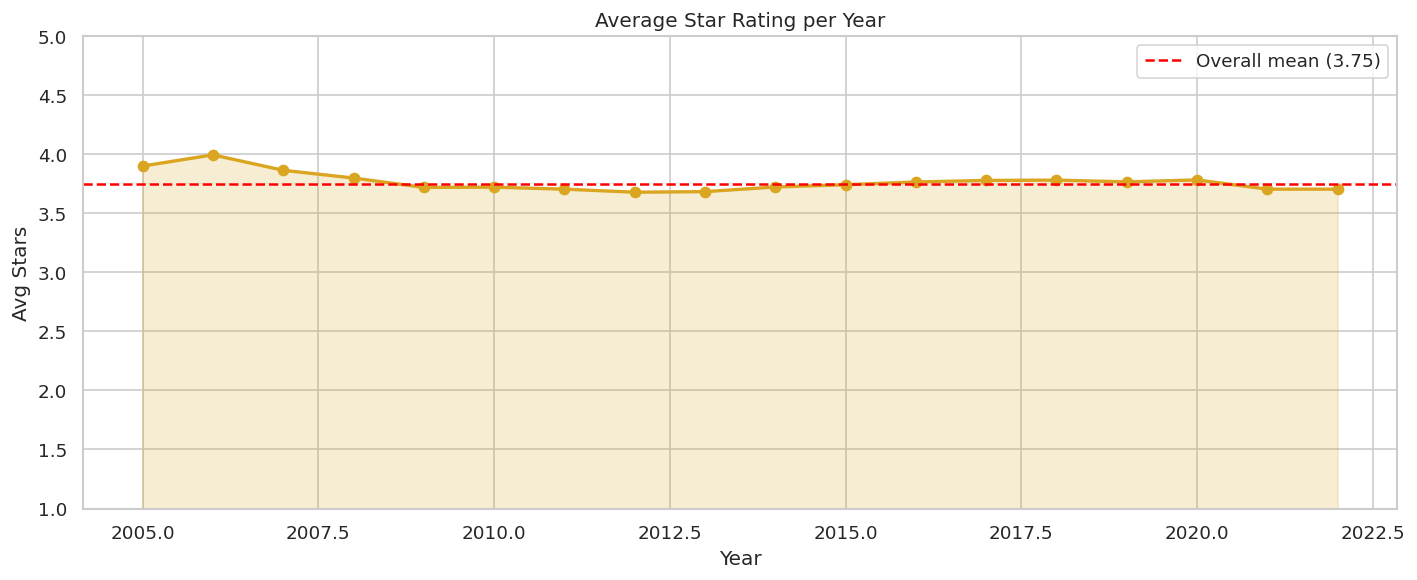

In [0]:
yearly_stars = df.groupby("year")["stars"].mean().reset_index()
yearly_stars = yearly_stars[yearly_stars["year"].between(2005, 2024)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(yearly_stars["year"], yearly_stars["stars"], marker="o", color="goldenrod", linewidth=2)
ax.fill_between(yearly_stars["year"], yearly_stars["stars"], alpha=0.2, color="goldenrod")
ax.set_title("Average Star Rating per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Avg Stars")
ax.set_ylim(1, 5)
ax.axhline(df["stars"].mean(), color="red", linestyle="--", label=f"Overall mean ({df['stars'].mean():.2f})")
ax.legend()
plt.tight_layout()
plt.show()

## 7 · Useful / Funny / Cool Vote Analysis

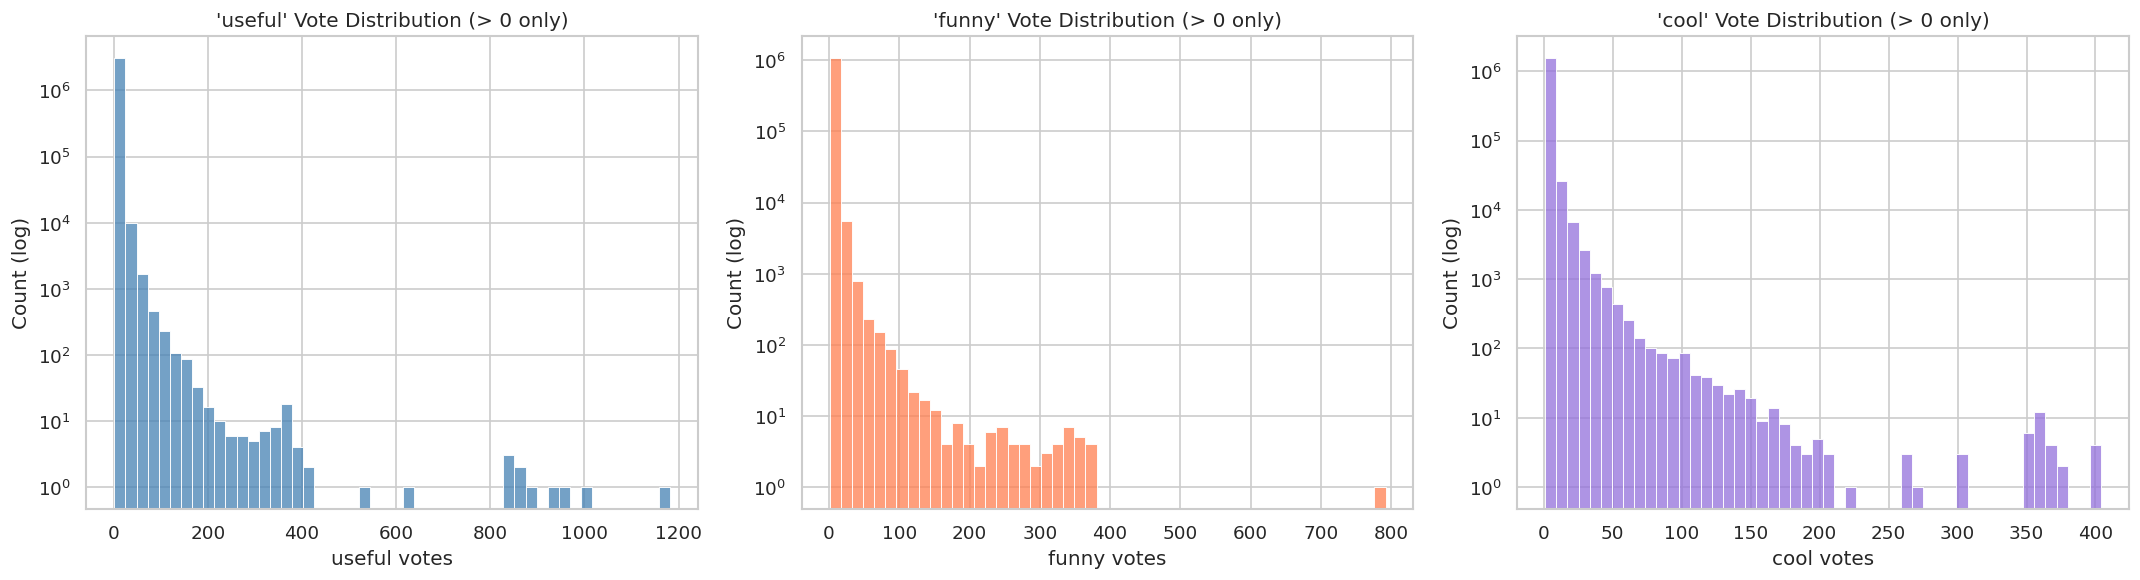

             useful         funny          cool
count  6.990280e+06  6.990280e+06  6.990280e+06
mean   1.184609e+00  3.265596e-01  4.986175e-01
std    3.253767e+00  1.688729e+00  2.172460e+00
min   -1.000000e+00 -1.000000e+00 -1.000000e+00
25%    0.000000e+00  0.000000e+00  0.000000e+00
50%    0.000000e+00  0.000000e+00  0.000000e+00
75%    1.000000e+00  0.000000e+00  0.000000e+00
max    1.182000e+03  7.920000e+02  4.040000e+02

Reviews with 0 useful: 3,840,492  (54.9%)


In [0]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, color in zip(axes, ["useful","funny","cool"], ["steelblue","coral","mediumpurple"]):
    data = df[col][df[col] > 0]
    sns.histplot(data, bins=50, ax=ax, color=color, log_scale=(False, True))
    ax.set_title(f"'{col}' Vote Distribution (> 0 only)")
    ax.set_xlabel(f"{col} votes")
    ax.set_ylabel("Count (log)")
plt.tight_layout()
plt.show()

print(df[["useful","funny","cool"]].describe())
print(f"\nReviews with 0 useful: {(df['useful']==0).sum():,}  ({(df['useful']==0).mean()*100:.1f}%)")

## 8 · Stars vs Vote Counts

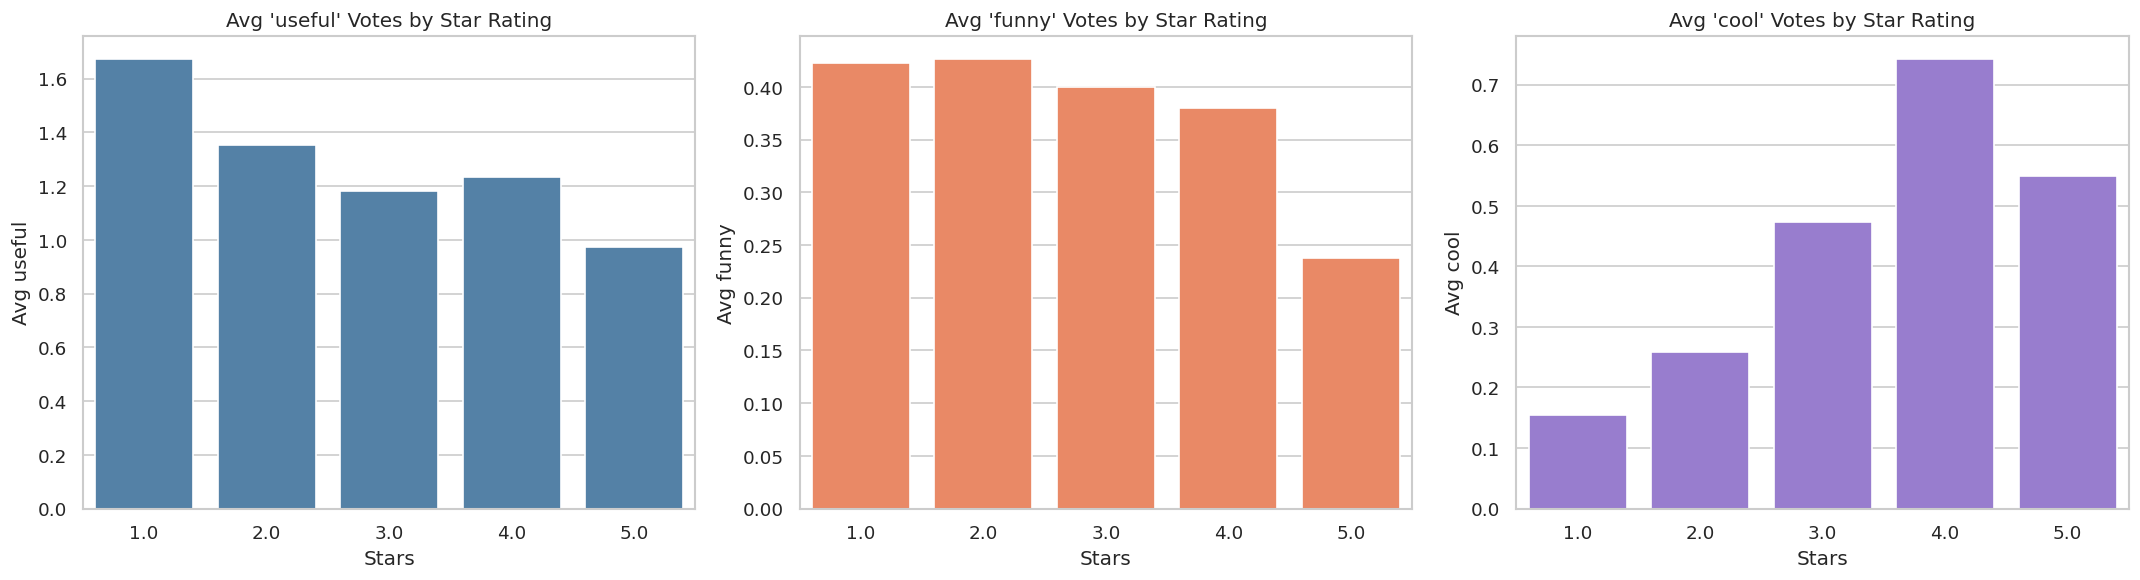

In [0]:
vote_star = df.groupby("stars")[["useful","funny","cool"]].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, color in zip(axes, ["useful","funny","cool"], ["steelblue","coral","mediumpurple"]):
    sns.barplot(data=vote_star, x="stars", y=col, ax=ax, color=color)
    ax.set_title(f"Avg '{col}' Votes by Star Rating")
    ax.set_xlabel("Stars")
    ax.set_ylabel(f"Avg {col}")
plt.tight_layout()
plt.show()

## 9 · Review Length Analysis

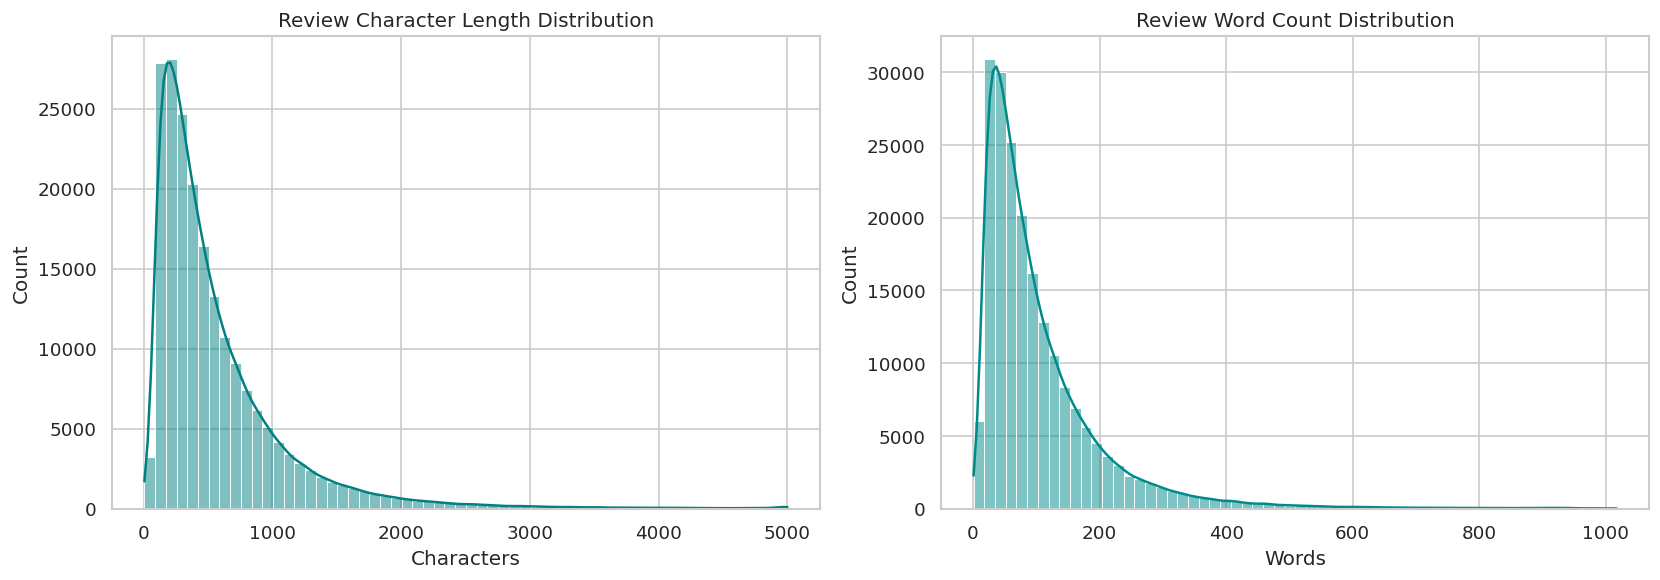

            text_len     word_count
count  200000.000000  200000.000000
mean      568.378355     104.869335
std       532.011017      98.763271
min         7.000000       1.000000
25%       229.000000      42.000000
50%       405.000000      75.000000
75%       720.000000     133.000000
max      5000.000000    1017.000000


In [0]:
sample_df = df.sample(min(SAMPLE_FOR_TEXT, len(df)), random_state=42) if SAMPLE_FOR_TEXT else df
sample_df = sample_df.copy()
sample_df["text_len"] = sample_df["text"].fillna("").apply(len)
sample_df["word_count"] = sample_df["text"].fillna("").apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(sample_df["text_len"], bins=60, ax=axes[0], color="teal", kde=True)
axes[0].set_title("Review Character Length Distribution")
axes[0].set_xlabel("Characters")

sns.histplot(sample_df["word_count"], bins=60, ax=axes[1], color="darkcyan", kde=True)
axes[1].set_title("Review Word Count Distribution")
axes[1].set_xlabel("Words")

plt.tight_layout()
plt.show()

print(sample_df[["text_len","word_count"]].describe())

## 10 · Review Length vs Stars

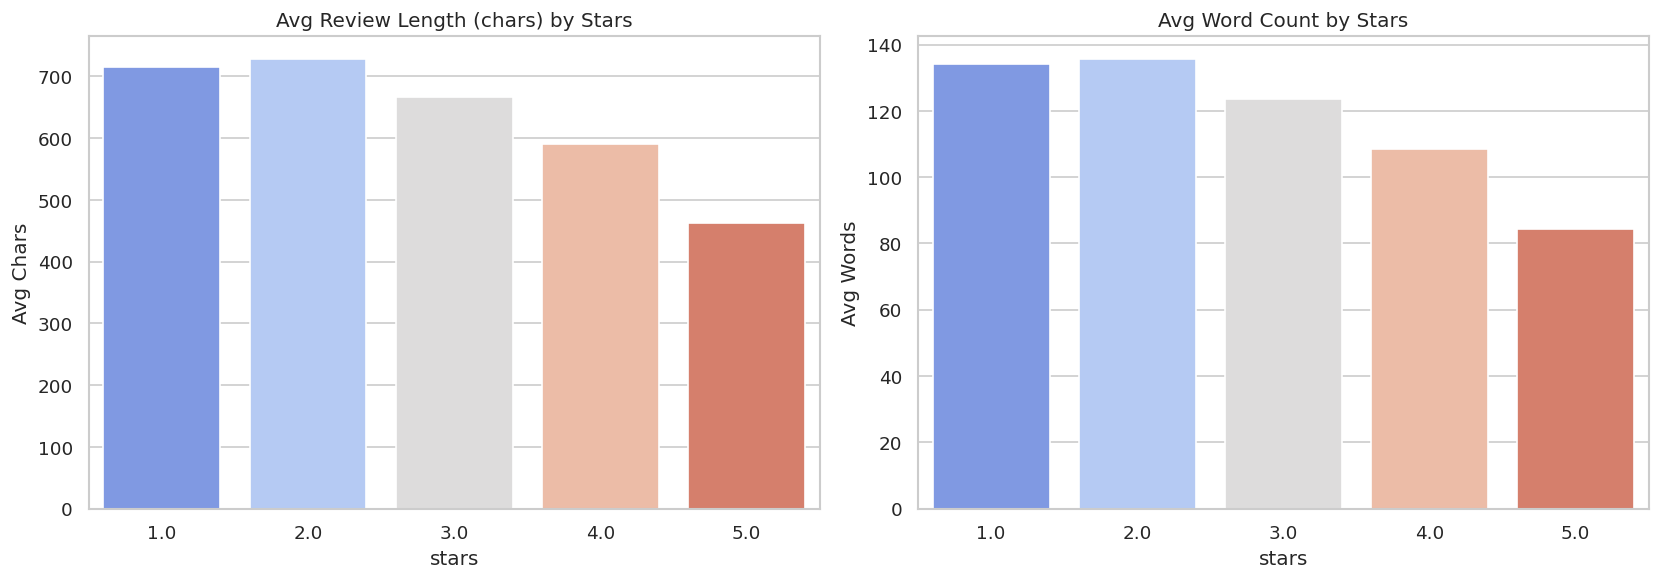

In [0]:
avg_len_by_star = sample_df.groupby("stars")[["text_len","word_count"]].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=avg_len_by_star, x="stars", y="text_len", ax=axes[0], palette="coolwarm")
axes[0].set_title("Avg Review Length (chars) by Stars")
axes[0].set_ylabel("Avg Chars")

sns.barplot(data=avg_len_by_star, x="stars", y="word_count", ax=axes[1], palette="coolwarm")
axes[1].set_title("Avg Word Count by Stars")
axes[1].set_ylabel("Avg Words")

plt.tight_layout()
plt.show()

## 11 · Most Active Reviewers

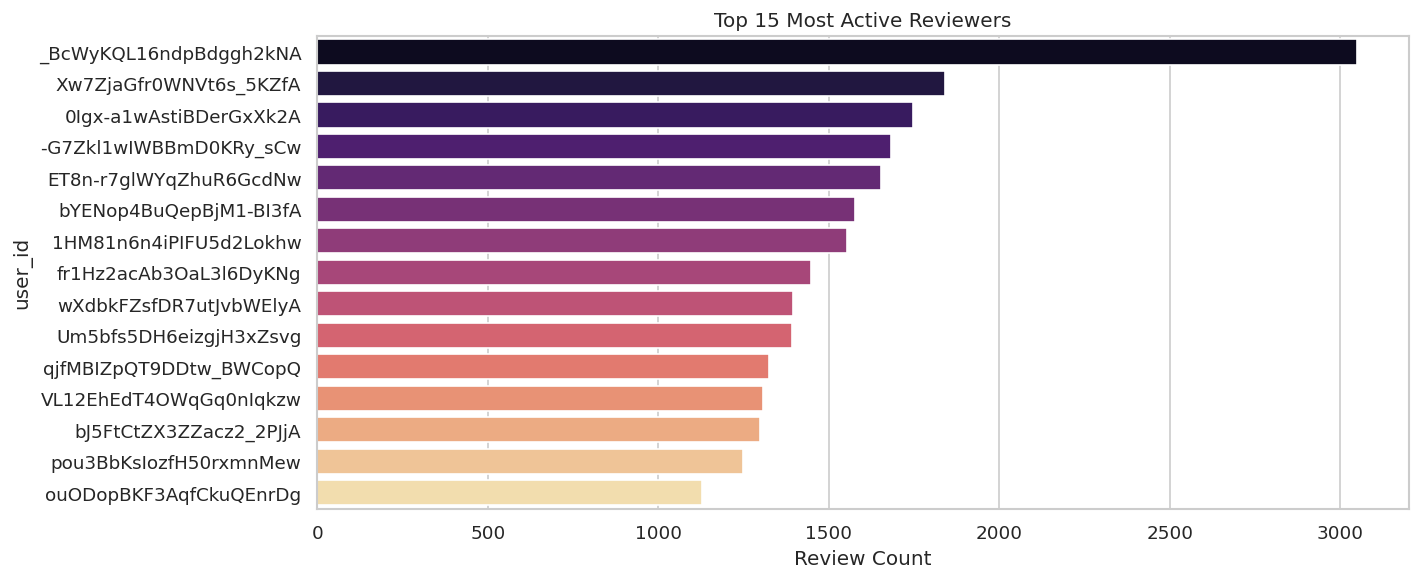

In [0]:
top_users = df["user_id"].value_counts().head(15).reset_index()
top_users.columns = ["user_id","review_count"]

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=top_users, x="review_count", y="user_id", ax=ax, palette="magma")
ax.set_title("Top 15 Most Active Reviewers")
ax.set_xlabel("Review Count")
plt.tight_layout()
plt.show()

## 12 · Most Reviewed Businesses

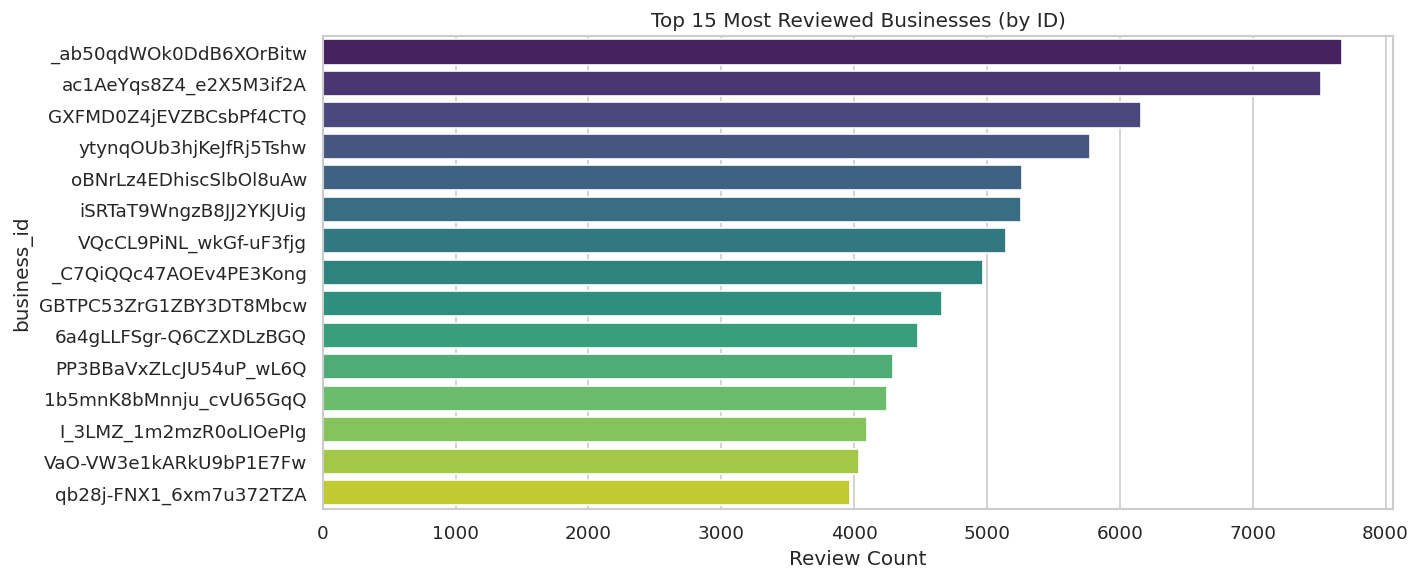

In [0]:
top_biz = df["business_id"].value_counts().head(15).reset_index()
top_biz.columns = ["business_id","review_count"]

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=top_biz, x="review_count", y="business_id", ax=ax, palette="viridis")
ax.set_title("Top 15 Most Reviewed Businesses (by ID)")
ax.set_xlabel("Review Count")
plt.tight_layout()
plt.show()

## 13 · Day-of-Week Review Pattern

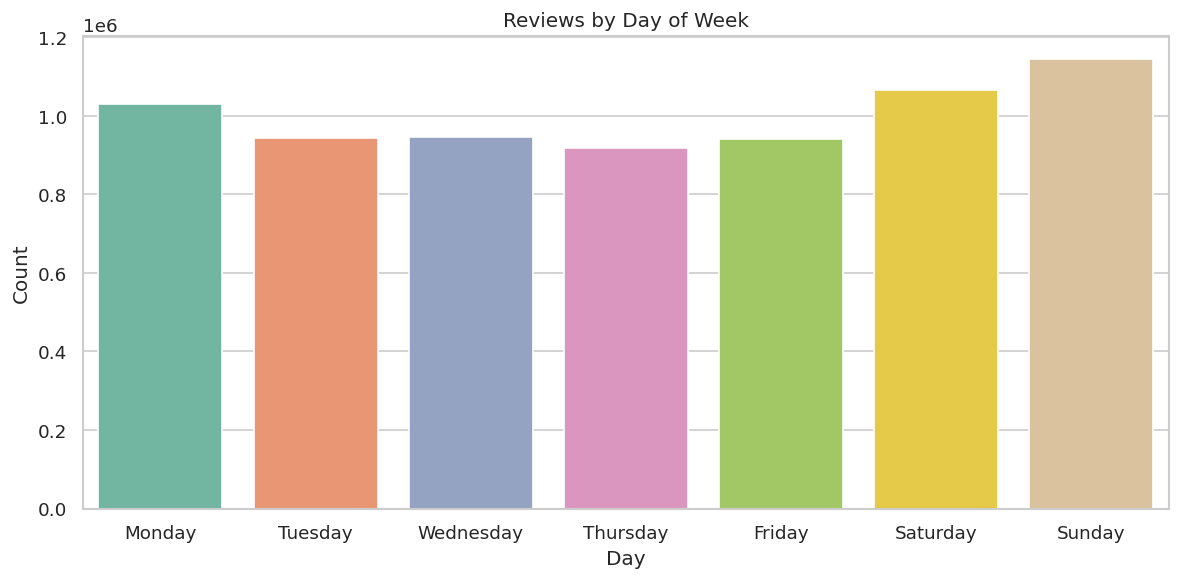

In [0]:
df["day_of_week"] = df["date"].dt.day_name()
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_counts = df["day_of_week"].value_counts().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=dow_counts.index, y=dow_counts.values, ax=ax, palette="Set2")
ax.set_title("Reviews by Day of Week")
ax.set_ylabel("Count")
ax.set_xlabel("Day")
plt.tight_layout()
plt.show()

## 14 · Star Heatmap: Month × Day of Week

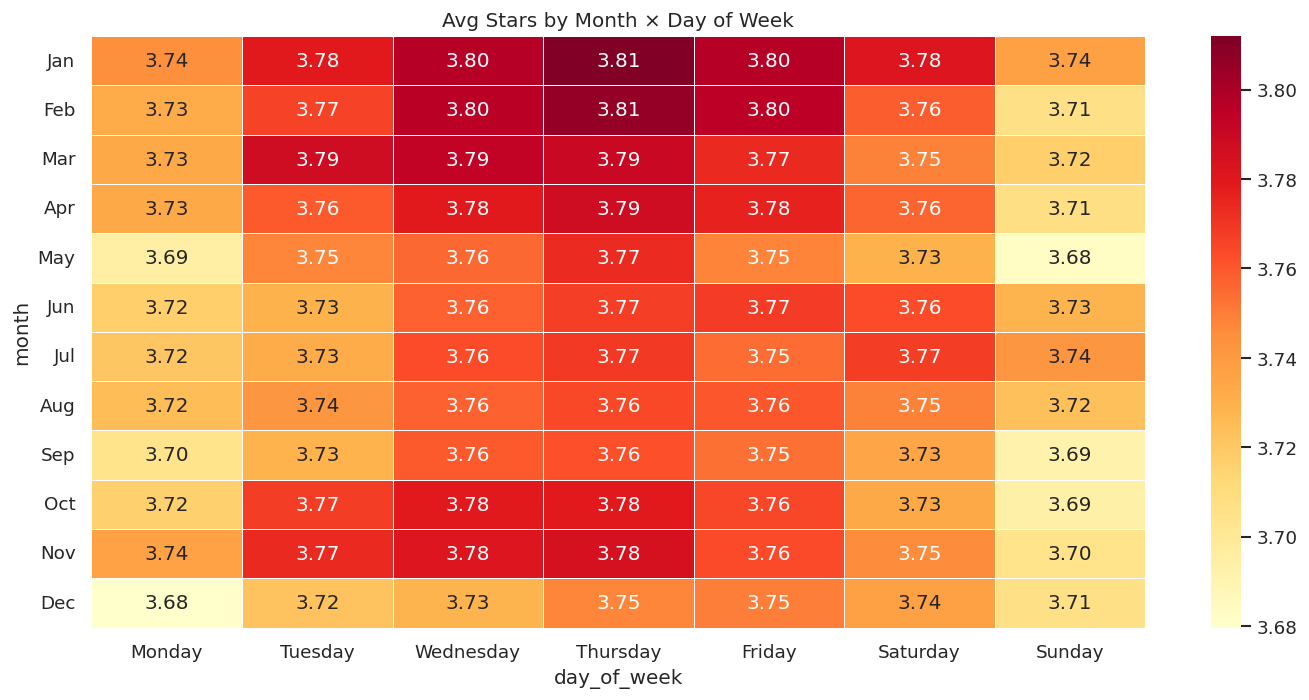

In [0]:
pivot = df.groupby(["month","day_of_week"])["stars"].mean().unstack().reindex(columns=day_order)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax, linewidths=0.5)
ax.set_title("Avg Stars by Month × Day of Week")
ax.set_yticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"], rotation=0)
plt.tight_layout()
plt.show()

## 15 · Summary

In [0]:
summary = pd.DataFrame({
    "Metric": [
        "Total Reviews",
        "Unique Users",
        "Unique Businesses",
        "Avg Stars",
        "Avg Review Length (chars)",
        "Avg Word Count",
        "% 5-star Reviews",
        "% 1-star Reviews",
        "Date Range",
    ],
    "Value": [
        f"{len(df):,}",
        f"{df['user_id'].nunique():,}",
        f"{df['business_id'].nunique():,}",
        f"{df['stars'].mean():.2f}",
        f"{sample_df['text_len'].mean():.0f}",
        f"{sample_df['word_count'].mean():.0f}",
        f"{(df['stars']==5).mean()*100:.1f}%",
        f"{(df['stars']==1).mean()*100:.1f}%",
        f"{df['date'].min().date()} → {df['date'].max().date()}",
    ]
})
display(summary)

Metric,Value
Total Reviews,"6,990,280"
Unique Users,"1,987,929"
Unique Businesses,"150,346"
Avg Stars,3.75
Avg Review Length (chars),568
Avg Word Count,105
% 5-star Reviews,46.2%
% 1-star Reviews,15.3%
Date Range,2005-02-16 → 2022-01-19


## ✅ Review EDA Complete
**Key Insights:**
- Reviews skew positive (most reviews are 4–5 stars)
- 1-star reviews tend to be longer than 5-star reviews
- Review volume grew steadily until ~2019 then dipped (COVID effect visible)
- Weekends see slightly more reviews and slightly higher ratings